MAX теоретический скор: 15.3846
MIN теоретический скор: -39.9434
Для скоров: Mean=-16.616  Std=7.403

Порог для p-value: 11.2281
Фактический p-value: 0.000110
  Число фоновых последовательностей : 100,000
  Средний скор: -16.6155
  Стд. отклонение: 7.4033
  MIN скор в выборке: -39.9434
  MAX скор в выборке: 13.3210
  Порог для p-value: 11.2281
  Фактический p-value при пороге: 1.10e-04
  Число хитов выше порога: 11


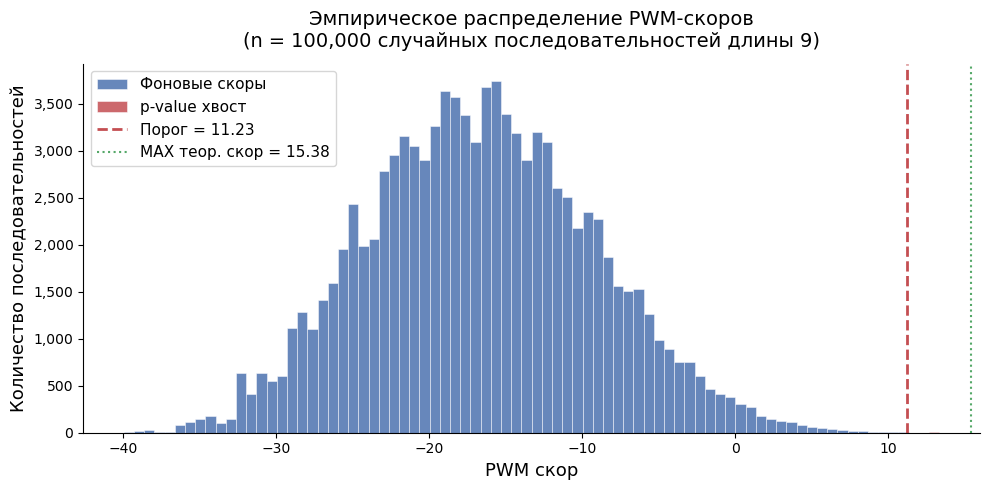

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# PWM 
NUCLEOTIDES = ["A", "C", "G", "T"]
BG = {"A": 0.295, "C": 0.205, "G": 0.205, "T": 0.295}
BG_PROBS = np.array([BG[n] for n in NUCLEOTIDES])   

sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC", "CAGGTTGGC",]
L = len(sites[0])  
N = len(sites)     
alpha = 0.1

# PFM
pfm = np.zeros((4, L), dtype=float)
for site in sites:
    for pos, nuc in enumerate(site):
        pfm[NUCLEOTIDES.index(nuc), pos] += 1

# PPM 
ppm = (pfm + alpha) / (N + 4 * alpha)

# PWM
pwm = np.log2(ppm / BG_PROBS.reshape(-1, 1))   

print(f"MAX теоретический скор: {pwm.max(axis=0).sum():.4f}")
print(f"MIN теоретический скор: {pwm.min(axis=0).sum():.4f}")


#  генератор случайных последовательностей 
def generate_random_sequences(n: int, length: int, bg: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    
    return rng.choice(4, size=(n, length), p=bg)


N_SEQS = 100_000
rng = np.random.default_rng(seed=42)
seqs = generate_random_sequences(N_SEQS, L, BG_PROBS, rng)  

# считаем PWM для всех последовательностей 
def score_sequences(seqs: np.ndarray, pwm: np.ndarray) -> np.ndarray:

    col_idx = np.arange(pwm.shape[1])
    scores = pwm[seqs, col_idx].sum(axis=1) 
    return scores

scores = score_sequences(seqs, pwm)
print(f"Для скоров: Mean={scores.mean():.3f}  Std={scores.std():.3f}")


# p-value
def get_pvalue(score: float, background_scores: np.ndarray) -> float:
    return float((background_scores >= score).mean())

target_pvalue = 1e-4
threshold_empirical = float(np.quantile(scores, 1 - target_pvalue))
actual_pvalue = get_pvalue(threshold_empirical, scores)

print(f"\nПорог для p-value: {threshold_empirical:.4f}")
print(f"Фактический p-value: {actual_pvalue:.6f}")

# рисуем гистограмму 
fig, ax = plt.subplots(figsize=(10, 5))
n_bins = 80
counts, bin_edges, patches = ax.hist( scores, bins=n_bins, color="#4C72B0", edgecolor="white", linewidth=0.4, alpha=0.85, label="Фоновые скоры")

for patch, left in zip(patches, bin_edges[:-1]):
    if left >= threshold_empirical:
        patch.set_facecolor("#C44E52")
        patch.set_label("p-value хвост")
ax.axvline(threshold_empirical, color="#C44E52", linewidth=2,
           linestyle="--", label=f"Порог = {threshold_empirical:.2f}  ")
max_score = pwm.max(axis=0).sum()
ax.axvline(max_score, color="#55A868", linewidth=1.5,
           linestyle=":", label=f"MAX теор. скор = {max_score:.2f}")

ax.set_xlabel("PWM скор", fontsize=13)
ax.set_ylabel("Количество последовательностей", fontsize=13)
ax.set_title(f"Эмпирическое распределение PWM-скоров\n"f"(n = {N_SEQS:,} случайных последовательностей длины {L})",fontsize=14, pad=12)

handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

print(f"  Число фоновых последовательностей : {N_SEQS:,}")
print(f"  Средний скор: {scores.mean():.4f}")
print(f"  Стд. отклонение: {scores.std():.4f}")
print(f"  MIN скор в выборке: {scores.min():.4f}")
print(f"  MAX скор в выборке: {scores.max():.4f}")
print(f"  Порог для p-value: {threshold_empirical:.4f}")
print(f"  Фактический p-value при пороге: {actual_pvalue:.2e}")
print(f"  Число хитов выше порога: {int(actual_pvalue * N_SEQS)}")